In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

วัตถุประสงค์: ทำนายว่าลูกค้าคนใด “มีแนวโน้มจะซื้อจักรยาน” หรือไม่ (Yes / No)

Target (เป้าหมาย): Purchased Bike — บอกว่าซื้อหรือไม่

''' เป้าหมายของโปรเจกต์นี้คือ

ต้องการดูว่าลูกค้าคนไหน “มีแนวโน้มที่จะซื้อจักรยาน” จากปัจจัยต่าง ๆ เช่น

รายได้ อายุ การมีรถยนต์ หรือสถานะสมรส ''''


In [108]:
data = pd.read_csv('bike_buyers.csv')
data

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,23731,Married,Male,60000.0,2.0,High School,Professional,Yes,2.0,2-5 Miles,North America,54.0,Yes
996,28672,Single,Male,70000.0,4.0,Graduate Degree,Professional,Yes,0.0,2-5 Miles,North America,35.0,Yes
997,11809,Married,NaN,60000.0,2.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,North America,38.0,Yes
998,19664,Single,Male,100000.0,3.0,Bachelors,Management,No,3.0,1-2 Miles,North America,38.0,No


In [110]:
data.shape

(1000, 13)

In [112]:
data.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000.0,1.0,Bachelors,Skilled Manual,Yes,0.0,0-1 Miles,Europe,42.0,No
1,24107,Married,Male,30000.0,3.0,Partial College,Clerical,Yes,1.0,0-1 Miles,Europe,43.0,No
2,14177,Married,Male,80000.0,5.0,Partial College,Professional,No,2.0,2-5 Miles,Europe,60.0,No
3,24381,Single,NaN,70000.0,0.0,Bachelors,Professional,Yes,1.0,5-10 Miles,Pacific,41.0,Yes
4,25597,Single,Male,30000.0,0.0,Bachelors,Clerical,No,0.0,0-1 Miles,Europe,36.0,Yes


In [114]:
data.isnull().sum()

ID                   0
Marital Status       7
Gender              11
Income               6
Children             8
Education            0
Occupation           0
Home Owner           4
Cars                 9
Commute Distance     0
Region               0
Age                  8
Purchased Bike       0
dtype: int64

In [116]:
data = data.drop_duplicates()

In [118]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna(data[col].mode()[0])
    else:
        data[col] = data[col].fillna(data[col].median())

In [120]:
data.isnull().sum()

ID                  0
Marital Status      0
Gender              0
Income              0
Children            0
Education           0
Occupation          0
Home Owner          0
Cars                0
Commute Distance    0
Region              0
Age                 0
Purchased Bike      0
dtype: int64

In [122]:
#ลบคอลัมน์ที่ไม่จำเป็น
if 'ID' in data.columns:
    data = data.drop(columns=['ID'])

In [124]:
data.columns.tolist()

['Marital Status',
 'Gender',
 'Income',
 'Children',
 'Education',
 'Occupation',
 'Home Owner',
 'Cars',
 'Commute Distance',
 'Region',
 'Age',
 'Purchased Bike']


Numeric correlation matrix:


,Income,Children,Cars,Age
Income,1.000000,0.258856,0.433564,0.170326
Children,0.258856,1.000000,0.275364,0.525683
Cars,0.433564,0.275364,1.000000,0.184295
Age,0.170326,0.525683,0.184295,1.000000


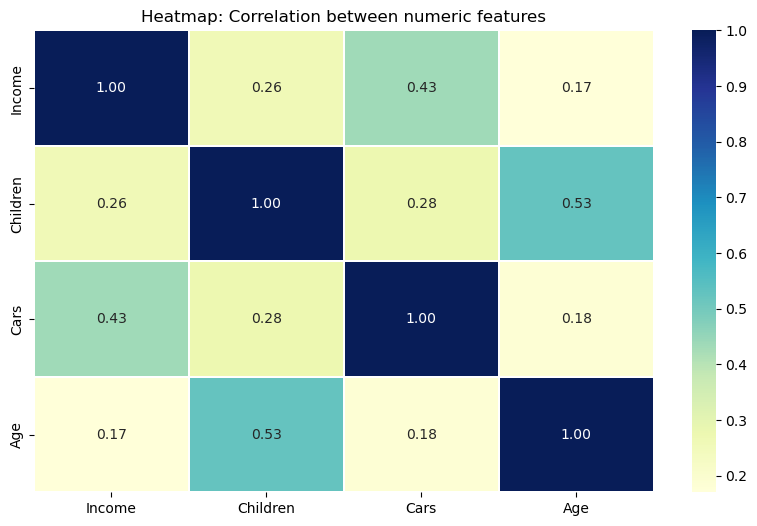

In [130]:
#Heatmap - correlation of numeric features
num_data = data.select_dtypes(include=[np.number])
if num_data.shape[1] >= 2:
    corr = num_data.corr()
    print("\nNumeric correlation matrix:")
    display(corr)
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.3)
    plt.title("Heatmap: Correlation between numeric features")
    plt.show()
else:
    print("\nNo numeric columns (or too few) for correlation heatmap.")

In [132]:
#แยก Features และ Target
# เป้าหมาย (Target)
y = data['Purchased Bike'].map({'No': 0, 'Yes': 1})

In [134]:
# ตัวแปรอิสระ (Features)
X = data.drop(columns=['Purchased Bike'])

In [136]:
#แปลงค่าข้อความให้เป็นตัวเลข (One-hot encoding)
X = pd.get_dummies(X, drop_first=True)

In [138]:
X.shape

(1000, 21)

In [140]:
y.shape

(1000,)

In [142]:
#แบ่งข้อมูล Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42, stratify=y)

Logistic Regression

In [145]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [147]:
# สร้างและเทรนโมเดล
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [149]:
#ประเมินผลโมเดล
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.64      0.69      0.67       104\n           1       0.64      0.58      0.61        96\n\n    accuracy                           0.64       200\n   macro avg       0.64      0.64      0.64       200\nweighted avg       0.64      0.64      0.64       200\n'

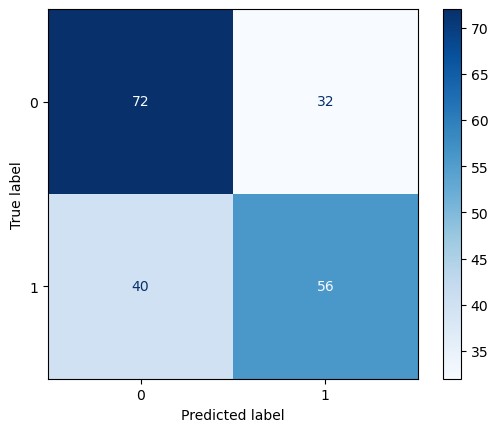

In [151]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')

In [153]:
 #Random Forest เพื่อเปรียบเทียบ

In [155]:
from sklearn.ensemble import RandomForestClassifier

In [157]:
log_reg_acc = accuracy_score(y_test, y_pred)

In [159]:
#Random Forest

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

In [161]:
# ปรียบเทียบผลลัพธ์
round(log_reg_acc, 4)
round(rf_acc, 4)

0.69

In [163]:
# แสดง Confusion Matrix ของ Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)

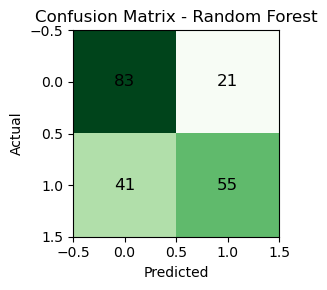

In [165]:
plt.figure(figsize=(4,3))
plt.imshow(rf_cm, cmap='Greens', interpolation='nearest')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for (i, j), v in np.ndenumerate(rf_cm):
    plt.text(j, i, str(v), ha='center', va='center', color='black', fontsize=12)
plt.tight_layout()
plt.show()

แสดงผลการเปรียบเทียบ Accuracy เป็นกราฟ

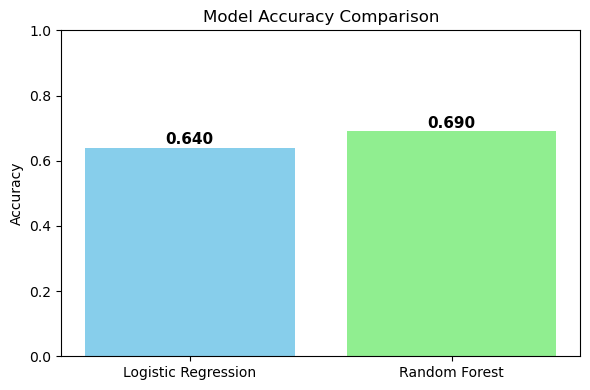

In [168]:
models = ['Logistic Regression', 'Random Forest']
accuracy = [log_reg_acc, rf_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=['skyblue', 'lightgreen'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11, fontweight='bold')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

ผลลัพธ์ที่ได้

โมเดล	Accuracy (ความแม่นยำ)	

Logistic Regression	

Random Forest แม่นยำกว่า, จัดการข้อมูลซับซ้อนได้ดี